# Google Matrix Analysis

This notebook contains the analysis of the an iterative Markov stochastic matrix making an analogy with the Google Matrix algorithm.

The Google Matrix is a stochastic matrix that is used by Google's PageRank algorithm to rank web pages in their search engine.

In [1]:
# Importing libraries
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

### Computing the Google Matrix

In [2]:
markov_matrix = np.array([
    # 1    2  3  4    5  6  (from)
    [  0, 1/2, 0, 0,   0, 0],  # 1 (to)
    [1/3,   0, 0, 0, 1/3, 0],  # 2
    [  0, 1/2, 0, 0,   0, 1],  # 3
    [1/3,   0, 0, 0, 1/3, 0],  # 4
    [1/3,   0, 0, 0,   0, 0],  # 5
    [  0,   0, 1, 0, 1/3, 0]   # 6 
    ])
print(markov_matrix.round(4))

# Create a directed graph
G = nx.DiGraph()
G.add_nodes_from(range(1, 7))
G.add_weighted_edges_from([(i + 1, j + 1, markov_matrix[i, j]) for i in range(6) for j in range(6) if markov_matrix[i, j] != 0])
G = G.reverse()  # Reverse to get the same graph as in the book

[[0.     0.5    0.     0.     0.     0.    ]
 [0.3333 0.     0.     0.     0.3333 0.    ]
 [0.     0.5    0.     0.     0.     1.    ]
 [0.3333 0.     0.     0.     0.3333 0.    ]
 [0.3333 0.     0.     0.     0.     0.    ]
 [0.     0.     1.     0.     0.3333 0.    ]]


Plotting the Google Matrix

1 -> 2: 0.50
2 -> 1: 0.33
2 -> 1: 0.33
1 -> 2: 0.50
3 -> 6: 1.00
6 -> 3: 1.00
6 -> 3: 1.00
3 -> 6: 1.00
None


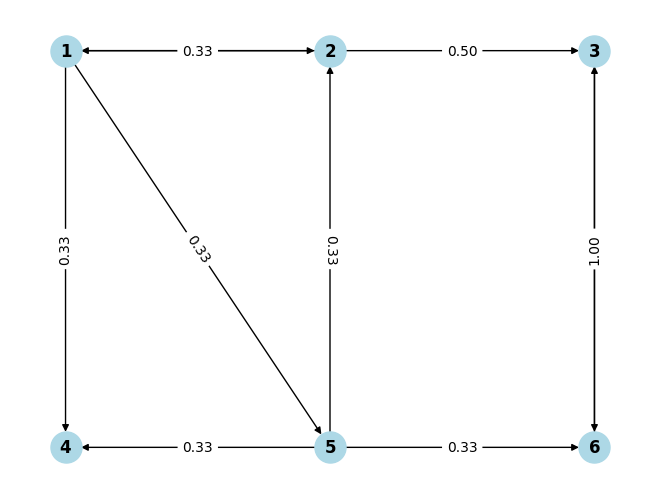

In [3]:

pos = {1: (0, 1), 2: (1, 1), 3: (2, 1), 4: (0, 0), 5: (1, 0), 6: (2, 0)}
nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=12, font_weight='bold', arrows=True)

# nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'weight'))
nx.draw_networkx_edge_labels(G, pos, edge_labels={(i, j): f'{markov_matrix[i - 1, j - 1]:.2f}' for i in range(1, 7) for j in range(1, 7) if markov_matrix[i - 1, j - 1] != 0})

def warn_bidirectial_edges(G):
    for i in range(1, G.number_of_nodes() + 1):
        for j in range(1, G.number_of_nodes() + 1):
            if G.has_edge(i, j) and G.has_edge(j, i):
                print('033[91m' + f'WARNING: node {i} & {j} have a bidirectional edge' + '033[0m')
                print(f'{i} -> {j}: {markov_matrix[i - 1, j - 1]:.2f}')
                print(f'{j} -> {i}: {markov_matrix[j - 1, i - 1]:.2f}')

print(warn_bidirectial_edges(G))

plt.show()

### Excercise 1
**Find the probability that the chain moves from state 1 to state 6 in exactly 5 steps.**

To solve this problem we need to compute the probability of the chain moving from state 1 to state 6 in exactly 5 steps. We can do this by computing the 5th power of the Google Matrix and then looking at the entry in the 1st row and 6th column.

In [4]:
n: int = 5  # number of steps

# Compute the Google matrix for any step n
google_matrix = np.linalg.matrix_power(markov_matrix, n)
print(f'Google matrix for {n} steps:n{google_matrix.round(4)}')

# Select the part of the matrix that represents the probability of going from node 1 to node 6
initial_node: int = 1
final_node: int = 6

print(f'nProbability of going from {initial_node} -> {final_node} in {n} steps: 033[92m{google_matrix[final_node - 1, initial_node - 1]:.4f}033[0m')

Google matrix for 5 steps:
[[0.0185 0.0139 0.     0.     0.0093 0.    ]
 [0.0154 0.0185 0.     0.     0.0093 0.    ]
 [0.2037 0.5972 0.     0.     0.0278 1.    ]
 [0.0154 0.0185 0.     0.     0.0093 0.    ]
 [0.0093 0.0093 0.     0.     0.0093 0.    ]
 [0.2006 0.0926 1.     0.     0.5278 0.    ]]

Probability of going from 1 -> 6 in 5 steps: 0.2006


### Excercise 2
**Explain why the transition matrix P you found in exercise 1 is not regular. Identify any dangling nodes in the graph and adjust the corresponding column(s) in the manner described above. Does the resulting matrix P* appear to be regular?**

In [5]:
def is_dangling_node(transition_matrix, node):
    # Check if the node is within the bounds of the transition matrix
    if node < 0 or node >= transition_matrix.shape[0]:
        raise ValueError("Node index is out of bounds")
    return np.all(transition_matrix[:, node] == 0)  # Check if all elements in the column are zero

# Find dangling nodes
dangling_nodes = [i for i in range(google_matrix.shape[0]) if is_dangling_node(google_matrix, i)]

print(f"Dangling nodes: {dangling_nodes}")
print(f"Values of the dangling nodes:n {google_matrix[:, dangling_nodes].round(4)}")

Dangling nodes: [3]
Values of the dangling nodes:
 [[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [6]:
# Adjust the Google matrix
# The node represents the column
p_star = markov_matrix.copy()
for node in dangling_nodes:
    p_star[:, node] = 1 / p_star.shape[0]

# google_matrix_adjusted = np.linalg.matrix_power(p_star, n)

# print(f"{p_star.round(4)}")   # print as default (white zeros)

def print_array_with_red_zeros(arr):
    rows, cols = arr.shape  # get the number of rows and columns
    for i in range(rows):  # iterate through the rows
        print("[", end=" ")  # print opening bracket
        for j in range(cols):  # iterate through the columns
            value = arr[i, j]  # get the value at the current row and column
            # print("033[91m0033[0m" if value == 0 else value, end=" ")
            # make the same print with an aligment to the right of 4 characters
            print(f"033[91m{value:.4f}033[0m" if value == 0 else f"{value:.4f}", end=" ")
        print("]", end="n" if i < rows - 1 else "]n")  # print closing bracket and new line if not the last row

print("nAdjusted Google matrix: (P*):")
print_array_with_red_zeros(p_star.round(4))

# get the dangling nodes of the adjusted matrix
dangling_nodes_adjusted = [i for i in range(p_star.shape[0]) if is_dangling_node(p_star, i)]

print(f"nDangling nodes of the adjusted matrix: {dangling_nodes_adjusted}")


Adjusted Google matrix: (P*):
[ 0.0000 0.5000 0.0000 0.1667 0.0000 0.0000 ]
[ 0.3333 0.0000 0.0000 0.1667 0.3333 0.0000 ]
[ 0.0000 0.5000 0.0000 0.1667 0.0000 1.0000 ]
[ 0.3333 0.0000 0.0000 0.1667 0.3333 0.0000 ]
[ 0.3333 0.0000 0.0000 0.1667 0.0000 0.0000 ]
[ 0.0000 0.0000 1.0000 0.1667 0.3333 0.0000 ]]

Dangling nodes of the adjusted matrix: []


The **`google_matrix` is not regular** because it contains columns with zeros. Specifically, column 4 contain only zeros, implying that there are no transitions from those states to other states. This means that stats 4 is unreachable from other states, making the matrix not regular.

The **`google_matrix_adjusted` is also not regular**. While it does not contain columns with zeros, **there are still states that are not reachable from other states**. For example, state 3 has no outgoing transitions to other states, making it an absorbing state.

### Excercise 3

**Identify the cycle in the network from exercise 1. Adjust the matrix P* that you found in exercise 2 by using the damping factor p = 0.75. Does the resulting matrix G appear to be regular?**

In a Markov chain, for the transition matrix to be regular, there must be a path from every state to every other state. If there are cycles in the network where a random surfer can get trapped, it prevents the transition matrix from being regular. A **cycle occurs when a set of nodes forms a loop where the surfer can keep moving between them endlessly, never reaching other nodes**.

In [7]:
G = nx.DiGraph(markov_matrix)
scc = list(nx.strongly_connected_components(G))
# Sum 1 to all the elements on scc to get the node number
scc = [[node + 1 for node in component] for component in scc]

match any(len(component) > 1 for component in scc):   # Check if there are SCCs with more than one node
    case True: 
        print("Cycles exist in the network, and the matrix is not regular.")
        print(f"Strongly connected components: {scc}")
    case False: 
        print("No cycles found, and the matrix is regular.")

Cycles exist in the network, and the matrix is not regular.
Strongly connected components: [[1, 2, 5], [3, 6], [4]]


In [8]:
def apply_teleportation(transition_matrix, p) -> np.ndarray:
    num_nodes = transition_matrix.shape[0]
    teleportation_matrix = np.full((num_nodes, num_nodes), 1.0 / num_nodes)  # 1/n matrix
    return (p * transition_matrix) + ((1 - p) * teleportation_matrix)

p: float = 0.75  # Apply teleportation with a 0.75 factor
google_matrix_teleported = apply_teleportation(p_star, p)

print(f"Teleported Google matrix (G):n{google_matrix_teleported.round(4)}")

Teleported Google matrix (G):
[[0.0417 0.4167 0.0417 0.1667 0.0417 0.0417]
 [0.2917 0.0417 0.0417 0.1667 0.2917 0.0417]
 [0.0417 0.4167 0.0417 0.1667 0.0417 0.7917]
 [0.2917 0.0417 0.0417 0.1667 0.2917 0.0417]
 [0.2917 0.0417 0.0417 0.1667 0.0417 0.0417]
 [0.0417 0.0417 0.7917 0.1667 0.2917 0.0417]]


**Can you think of a natural argument in favor of the teleportation matrix? How might it reflect the behavior of actual people surfing the internet? Write a short response**

In essence, the teleportation matrix accounts for the inherent unpredictability and randomness in human internet browsing, making the PageRank algorithm more robust and relevant to user behavior. It helps avoid the potential problem of "spider traps" or "dead ends" in a graph, ensuring that users can always navigate through the web, even when there are dangling nodes or disconnected components.

### Excercise 4

**To find the steady-state vector q for the given transition matrix G, you can solve the equation Gq = q. The steady-state vector represents the occupation times for each state in the Markov chain and can be used to rank the pages from most important to least important. The steady-state vector is a probability distribution over the states.**

**Initial State**:
- Initialize the state vector $(q)$ with length $(n)$ as:
- $q = \frac{1}{n}\begin{bmatrix} 1 \\ 1 \\ \vdots \\ 1 \end{bmatrix}$

**Iteration**:
- During each iteration $(k)$, update $(q)$ based on matrix-vector multiplication:
  $q^{(k+1)} = [m \cdot q^{(k)}]$

**Normalization**:
- After each iteration, normalize (q) to ensure it sums to 1:
  $[q^{(k+1)} = \frac{q^{(k+1)}}{|q^{(k+1)}|_1}]$

**Results**:
- The final stationary state vector is $(q)$.

The PageRank is calculated based on this final $(q)$ vector, providing the relative importance of web pages based on their link structure.

In [17]:
m = google_matrix_teleported
max_iterations: int = 1000
tolerance = 1e-6

q = np.ones(m.shape[0]) / m.shape[0]  # Initial state vector

for iteration in range(max_iterations):
    q_prev = q.copy()
    q = [np.dot(m[i, :], q) for i in range(m.shape[0])]

q /= np.sum(q)  # Normalización del vector q

print(f"Vector de estado estacionario (q):n{q}")
print(f"nPage Ranking (from most important to least important):n{np.argsort(-q) + 1}")

Vector de estado estacionario (q):
[0.08901515 0.09469697 0.32765152 0.09469697 0.07575758 0.31818182]

Page Ranking (from most important to least important):
[3 6 2 4 1 5]


**If Google uses this algorithm to rank pages, how could it be manipulated to increase the rank of a page? How could Google modify the algorithm to combat such manipulation and improve the accuracy and usefulness of their search results?**

If Google uses the PageRank algorithm to rank pages, it can be manipulated by webmasters and content creators to increase the rank of their pages. Some common tactics include creating an extensive network of inbound and outbound links to artificially inflate a page's perceived importance, implementing keyword stuffing, or engaging in link schemes with other websites. These manipulative practices aim to exploit the link structure of the web to make a page appear more authoritative than it actually is. While they might temporarily boost a page's ranking, such tactics can undermine the quality and relevance of search results, which goes against Google's mission of providing users with useful and accurate information.

To combat such manipulation and improve the accuracy and usefulness of their search results, Google can employ several strategies. One approach is to continuously refine and evolve the PageRank algorithm, introducing more sophisticated methods to evaluate the quality and relevance of web pages. Google has already done this by incorporating hundreds of ranking factors into its algorithms, including user behavior, content quality, and mobile-friendliness. Additionally, Google can invest in machine learning and natural language processing techniques to better understand the context and semantics of web content, making it harder for manipulative tactics to succeed.

Furthermore, Google can implement stricter policies and algorithms to detect and penalize manipulative practices, such as link spam and keyword stuffing. Regular algorithm updates and manual review processes can help identify and penalize websites that engage in such activities. Ultimately, Google's efforts should focus on rewarding high-quality, user-friendly content and ensuring that its ranking algorithms prioritize relevance and authority rather than artificial link-building or keyword stuffing. This continuous evolution and commitment to improving search quality are essential in maintaining trust and delivering valuable search results to users.